In [1]:
import os, json, pickle, glob, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde, ks_2samp, wasserstein_distance

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 140, "font.size": 11})

# ── Only line you ever change ──────────────────────────────────────────────────
BASE_DIR = r"C:\workplace\adaptive_tracer\micro-service-trace-data"
# ──────────────────────────────────────────────────────────────────────────────

CATS_LIST     = [4, 6, 8, 10]
ANOMALY_TYPES = ["cpu", "disk", "mem", "net"]
SPLITS = (
    ["train_id", "valid_id", "test_id"] +
    [f"valid_ood_{a}" for a in ANOMALY_TYPES] +
    [f"test_ood_{a}"  for a in ANOMALY_TYPES]
)

COLORS_NORMAL  = ["steelblue", "orange", "seagreen"]
COLORS_ANOMALY = ["crimson", "purple", "saddlebrown", "magenta"]
COLOR_MAP = dict(zip(
    ["train_id","valid_id","test_id"] + [f"test_ood_{a}" for a in ANOMALY_TYPES],
    COLORS_NORMAL + COLORS_ANOMALY
))

def cats_dir(cats):
    return os.path.join(BASE_DIR, f"preprocessed_cats{cats}")

print("BASE_DIR exists:", os.path.isdir(BASE_DIR))
for c in CATS_LIST:
    print(f"  preprocessed_cats{c} exists:", os.path.isdir(cats_dir(c)))


BASE_DIR exists: True
  preprocessed_cats4 exists: True
  preprocessed_cats6 exists: True
  preprocessed_cats8 exists: True
  preprocessed_cats10 exists: True


In [2]:
vocabs, delay_all = {}, {}

for cats in CATS_LIST:
    vp = os.path.join(cats_dir(cats), "vocab.pkl")
    dp = os.path.join(cats_dir(cats), "delay_spans.pkl")
    if not os.path.isfile(vp):
        print(f"  ❌ MISSING vocab cats{cats}"); continue
    if not os.path.isfile(dp):
        print(f"  ❌ MISSING delay_spans cats{cats}"); continue

    with open(vp, "rb") as f:
        vocabs[cats] = pickle.load(f)         # (dict_sys, dict_proc)
    with open(dp, "rb") as f:
        delay_all[cats] = pickle.load(f)      # {syscall: (boundaries, count)}

    dict_sys, dict_proc = vocabs[cats]
    ds = delay_all[cats]
    print(f"\ncats{cats}:")
    print(f"  Syscall vocab  : {len(dict_sys.word2idx):,} tokens")
    print(f"  Process vocab  : {len(dict_proc.word2idx):,} tokens")
    print(f"  Delay spans    : {len(ds):,} syscall types")

    # Verify boundary count matches n_categories
    sample = next(iter(ds.values()))
    bounds, _ = sample
    n_boundaries = len(bounds)
    expected = cats - 2          # cats=6 → 5 boundaries → 5 real bins + pad=0
    ok = n_boundaries == expected
    print(f"  Boundary count : {n_boundaries}  (expected {expected})  {'✅' if ok else '❌ MISMATCH'}")

# Cross-cats vocab consistency
if 4 in vocabs and 6 in vocabs:
    v4 = set(vocabs[4][0].word2idx.keys())
    v6 = set(vocabs[6][0].word2idx.keys())
    print(f"\nVocab consistency cats4 vs cats6: identical={v4==v6}  "
          f"only_in_4={v4-v6}  only_in_6={v6-v4}")



cats4:
  Syscall vocab  : 257 tokens
  Process vocab  : 6 tokens
  Delay spans    : 77 syscall types
  Boundary count : 2  (expected 2)  ✅

cats6:
  Syscall vocab  : 257 tokens
  Process vocab  : 6 tokens
  Delay spans    : 77 syscall types
  Boundary count : 4  (expected 4)  ✅

cats8:
  Syscall vocab  : 257 tokens
  Process vocab  : 6 tokens
  Delay spans    : 77 syscall types
  Boundary count : 6  (expected 6)  ✅

cats10:
  Syscall vocab  : 257 tokens
  Process vocab  : 6 tokens
  Delay spans    : 77 syscall types
  Boundary count : 8  (expected 8)  ✅

Vocab consistency cats4 vs cats6: identical=True  only_in_4=set()  only_in_6=set()


In [3]:
import gc

# ── How many shards to load per split ─────────────────────────────────────
# None = load everything (needs ~6–8 GB RAM, likely too much on your machine)
# 5    = ~300 MB total, enough for all diagnostics
MAX_SHARDS = 5
# ──────────────────────────────────────────────────────────────────────────

def load_split(split_name, preproc_dir, max_shards=None):
    """Load shards for one split. Returns (dict_of_arrays, n_shards_total)."""
    split_dir = os.path.join(preproc_dir, split_name)
    shards    = sorted(glob.glob(os.path.join(split_dir, "shard_*.npz")))
    if not shards:
        return None, 0
    n_total = len(shards)
    if max_shards:
        shards = shards[:max_shards]

    # Pass 1: global padded length
    max_len = 0
    for p in shards:
        d = np.load(p, allow_pickle=False)
        for k in d.files:
            if d[k].ndim == 2:
                max_len = max(max_len, d[k].shape[1])

    # Pass 2: load & pad
    arrays = defaultdict(list)
    for p in shards:
        d = np.load(p, allow_pickle=False)
        for k in d.files:
            a = d[k]
            if a.ndim == 2 and a.shape[1] < max_len:
                a = np.pad(a, ((0, 0), (0, max_len - a.shape[1])))
            arrays[k].append(a)
    result = {k: np.concatenate(v, axis=0) for k, v in arrays.items()}
    return result, n_total


# ── Load one cats at a time, report RAM immediately ───────────────────────
all_data = {}
all_meta = {}

for cats in CATS_LIST:
    pdir = cats_dir(cats)
    all_data[cats] = {}
    all_meta[cats] = {}

    for split in SPLITS:
        meta_path = os.path.join(pdir, split, "meta.json")
        if os.path.isfile(meta_path):
            with open(meta_path) as f:
                all_meta[cats][split] = json.load(f)

        try:
            d, n_total = load_split(split, pdir, MAX_SHARDS)
        except MemoryError:
            print(f"  ⚠️  MemoryError on cats{cats}/{split} — reduce MAX_SHARDS further")
            gc.collect()
            d = None

        if d is not None:
            all_data[cats][split] = d

    loaded = list(all_data[cats].keys())
    print(f"cats{cats}: {len(loaded)}/11 splits loaded  "
          f"(MAX_SHARDS={MAX_SHARDS} of {n_total} per split)")

    # Show per-split shapes for this cats so you can confirm data is sensible
    for split in loaded:
        d = all_data[cats][split]
        print(f"    {split:<22} call.shape={d['call'].shape}  "
              f"dtype_call={d['call'].dtype}")

    gc.collect()   # release any lingering buffers between cats iterations


# ── Detect canonical key names from first available split ─────────────────
_ex = None
for cats in CATS_LIST:
    for split in SPLITS:
        if split in all_data.get(cats, {}):
            _ex = all_data[cats][split]; break
    if _ex is not None: break

SEQ_LEN_KEY = "seq_len" if "seq_len" in _ex else "seqlen"
LAT_CAT_KEY = "lat_cat" if "lat_cat" in _ex else "latcat"
print(f"\nKey names:  seq_len='{SEQ_LEN_KEY}'   lat_cat='{LAT_CAT_KEY}'")
print(f"NPZ keys  : {list(_ex.keys())}")


cats4: 11/11 splits loaded  (MAX_SHARDS=5 of 45 per split)
    train_id               call.shape=(25000, 512)  dtype_call=int32
    valid_id               call.shape=(25000, 512)  dtype_call=int32
    test_id                call.shape=(25000, 512)  dtype_call=int32
    valid_ood_cpu          call.shape=(25000, 512)  dtype_call=int32
    valid_ood_disk         call.shape=(25000, 512)  dtype_call=int32
    valid_ood_mem          call.shape=(25000, 512)  dtype_call=int32
    valid_ood_net          call.shape=(25000, 512)  dtype_call=int32
    test_ood_cpu           call.shape=(25000, 512)  dtype_call=int32
    test_ood_disk          call.shape=(25000, 512)  dtype_call=int32
    test_ood_mem           call.shape=(25000, 512)  dtype_call=int32
    test_ood_net           call.shape=(25000, 512)  dtype_call=int32
cats6: 11/11 splits loaded  (MAX_SHARDS=5 of 45 per split)
    train_id               call.shape=(25000, 512)  dtype_call=int32
    valid_id               call.shape=(25000, 512)  dt

In [4]:
import sys

total_bytes = 0
for cats in CATS_LIST:
    for split, d in all_data.get(cats, {}).items():
        for arr in d.values():
            total_bytes += arr.nbytes

print(f"Total RAM used by all_data: {total_bytes / 1e9:.2f} GB")
print()
print("If this is above ~4 GB and you hit MemoryError in later cells,")
print("lower MAX_SHARDS in Cell 3 to 3 or 2 and rerun Cell 3 only.")
print()

# Quick per-cats breakdown
for cats in CATS_LIST:
    cats_bytes = sum(
        arr.nbytes
        for d in all_data.get(cats, {}).values()
        for arr in d.values()
    )
    print(f"  cats{cats}: {cats_bytes / 1e6:.0f} MB  "
          f"({len(all_data.get(cats,{}))} splits)")


Total RAM used by all_data: 15.22 GB

If this is above ~4 GB and you hit MemoryError in later cells,
lower MAX_SHARDS in Cell 3 to 3 or 2 and rerun Cell 3 only.

  cats4: 3804 MB  (11 splits)
  cats6: 3804 MB  (11 splits)
  cats8: 3804 MB  (11 splits)
  cats10: 3804 MB  (11 splits)


#cell 4

In [5]:
print(f"\n{'cats':<6} {'Split':<22} {'Seqs':>8} {'Shards':>7} "
      f"{'Anomaly':>8} {'AvgLen':>8} {'MaxLen':>8} {'meta_ok':>8}")
print("─" * 80)

for cats in CATS_LIST:
    for split in SPLITS:
        if split not in all_data[cats]:
            print(f"cats{cats}  {split:<22}  ── MISSING ──"); continue
        d  = all_data[cats][split]
        m  = all_meta[cats].get(split, {})
        ia = d["is_anomaly"].ravel()
        anom_flag = int(ia[0]) if len(np.unique(ia)) == 1 else "mixed"
        lens = d[SEQ_LEN_KEY].ravel()
        shards = len(sorted(glob.glob(
            os.path.join(cats_dir(cats), split, "shard_*.npz"))))
        print(f"cats{cats}  {split:<22} {len(d['call']):>8,} {shards:>7} "
              f"{str(anom_flag):>8} {lens.mean():>8.1f} "
              f"{int(lens.max()):>8} {'✅' if m else '❌':>8}")
    print()



cats   Split                      Seqs  Shards  Anomaly   AvgLen   MaxLen  meta_ok
────────────────────────────────────────────────────────────────────────────────
cats4  train_id                 25,000      64        0     98.5      512        ✅
cats4  valid_id                 25,000      64        0     98.5      512        ✅
cats4  test_id                  25,000      64        0     98.5      512        ✅
cats4  valid_ood_cpu            25,000      78        1     93.3      512        ✅
cats4  valid_ood_disk           25,000      86        1     82.9      512        ✅
cats4  valid_ood_mem            25,000      78        1     94.2      512        ✅
cats4  valid_ood_net            25,000      45        1     90.6      512        ✅
cats4  test_ood_cpu             25,000      78        1     93.3      512        ✅
cats4  test_ood_disk            25,000      86        1     82.9      512        ✅
cats4  test_ood_mem             25,000      78        1     94.2      512        ✅
cats4

#cell 5

In [6]:
print("=" * 68)
print("SANITY CHECKS")
print("=" * 68)

all_ok = True

for cats in CATS_LIST:
    print(f"\n── cats{cats} ──────────────────────────────────────────────────")
    d_data = all_data[cats]

    # 1. is_anomaly flags correct
    for split in SPLITS:
        if split not in d_data: continue
        ia = np.unique(d_data[split]["is_anomaly"].ravel())
        expected = [0] if "ood" not in split else [1]
        ok = list(ia) == expected
        all_ok = all_ok and ok
        print(f"  {'✅' if ok else '❌'} {split:<22} is_anomaly={list(ia)}  expected={expected}")

    # 2. lat_cat values in range [0, n_categories]
    for split in SPLITS:
        if split not in d_data: continue
        cats_arr = d_data[split][LAT_CAT_KEY].ravel()
        ok = int(cats_arr.max()) <= cats
        all_ok = all_ok and ok
        if not ok:
            print(f"  ❌ {split:<22} lat_cat max={cats_arr.max()} EXCEEDS n_cat={cats}")

    # 3. No NaN/Inf in duration
    for split in ["train_id", "test_id"]:
        if split not in d_data: continue
        bad = np.sum(~np.isfinite(d_data[split]["duration"].astype(np.float32)))
        ok  = bad == 0
        all_ok = all_ok and ok
        print(f"  {'✅' if ok else '❌'} {split:<22} non-finite durations={bad:,}")

    # 4. Sequence-length drift between train/valid/test (normal only)
    if all(s in d_data for s in ["train_id","valid_id","test_id"]):
        means = {s: d_data[s][SEQ_LEN_KEY].ravel().mean()
                 for s in ["train_id","valid_id","test_id"]}
        drift = max(means.values())/min(means.values()) - 1
        ok = drift < 0.15
        print(f"  {'✅' if ok else '⚠️ '} seq_len drift {drift*100:.1f}%   "
              f"train={means['train_id']:.1f}  valid={means['valid_id']:.1f}  test={means['test_id']:.1f}")

    # 5. CRITICAL: Do OOD splits have latency distribution collapse?
    #    If ALL sequences land in the same lat_cat, duration-only will be random.
    if "train_id" in d_data:
        ref_cats = d_data["train_id"][LAT_CAT_KEY].ravel()
        ref_cats = ref_cats[ref_cats > 0]
        ref_entropy = -sum((c/len(ref_cats))*np.log2(c/len(ref_cats)+1e-12)
                           for c in np.bincount(ref_cats)[1:] if c > 0)
        print(f"  ℹ️  train_id lat_cat entropy: {ref_entropy:.3f} bits")

        for atype in ANOMALY_TYPES:
            sp = f"test_ood_{atype}"
            if sp not in d_data: continue
            ood_cats = d_data[sp][LAT_CAT_KEY].ravel()
            ood_cats = ood_cats[ood_cats > 0]
            ood_entropy = -sum((c/len(ood_cats))*np.log2(c/len(ood_cats)+1e-12)
                               for c in np.bincount(ood_cats)[1:] if c > 0)
            ks_stat, ks_p = ks_2samp(
                ref_cats[:50_000].astype(float),
                ood_cats[:50_000].astype(float)
            )
            print(f"  ℹ️  test_ood_{atype:<4} lat_cat entropy: {ood_entropy:.3f} bits  "
                  f"KS={ks_stat:.4f}  p={ks_p:.2e}  "
                  f"{'✅ distribs differ' if ks_p < 0.05 else '❌ SAME DISTRIBUTION — latency signal absent'}")

print(f"\n{'✅ ALL CHECKS PASSED' if all_ok else '❌ SOME CHECKS FAILED — see above'}")


SANITY CHECKS

── cats4 ──────────────────────────────────────────────────
  ✅ train_id               is_anomaly=[np.int8(0)]  expected=[0]
  ✅ valid_id               is_anomaly=[np.int8(0)]  expected=[0]
  ✅ test_id                is_anomaly=[np.int8(0)]  expected=[0]
  ✅ valid_ood_cpu          is_anomaly=[np.int8(1)]  expected=[1]
  ✅ valid_ood_disk         is_anomaly=[np.int8(1)]  expected=[1]
  ✅ valid_ood_mem          is_anomaly=[np.int8(1)]  expected=[1]
  ✅ valid_ood_net          is_anomaly=[np.int8(1)]  expected=[1]
  ✅ test_ood_cpu           is_anomaly=[np.int8(1)]  expected=[1]
  ✅ test_ood_disk          is_anomaly=[np.int8(1)]  expected=[1]
  ✅ test_ood_mem           is_anomaly=[np.int8(1)]  expected=[1]
  ✅ test_ood_net           is_anomaly=[np.int8(1)]  expected=[1]
  ✅ train_id               non-finite durations=0
  ✅ test_id                non-finite durations=0
  ✅ seq_len drift 0.0%   train=98.5  valid=98.5  test=98.5
  ℹ️  train_id lat_cat entropy: 1.165 bits
  ℹ️  te

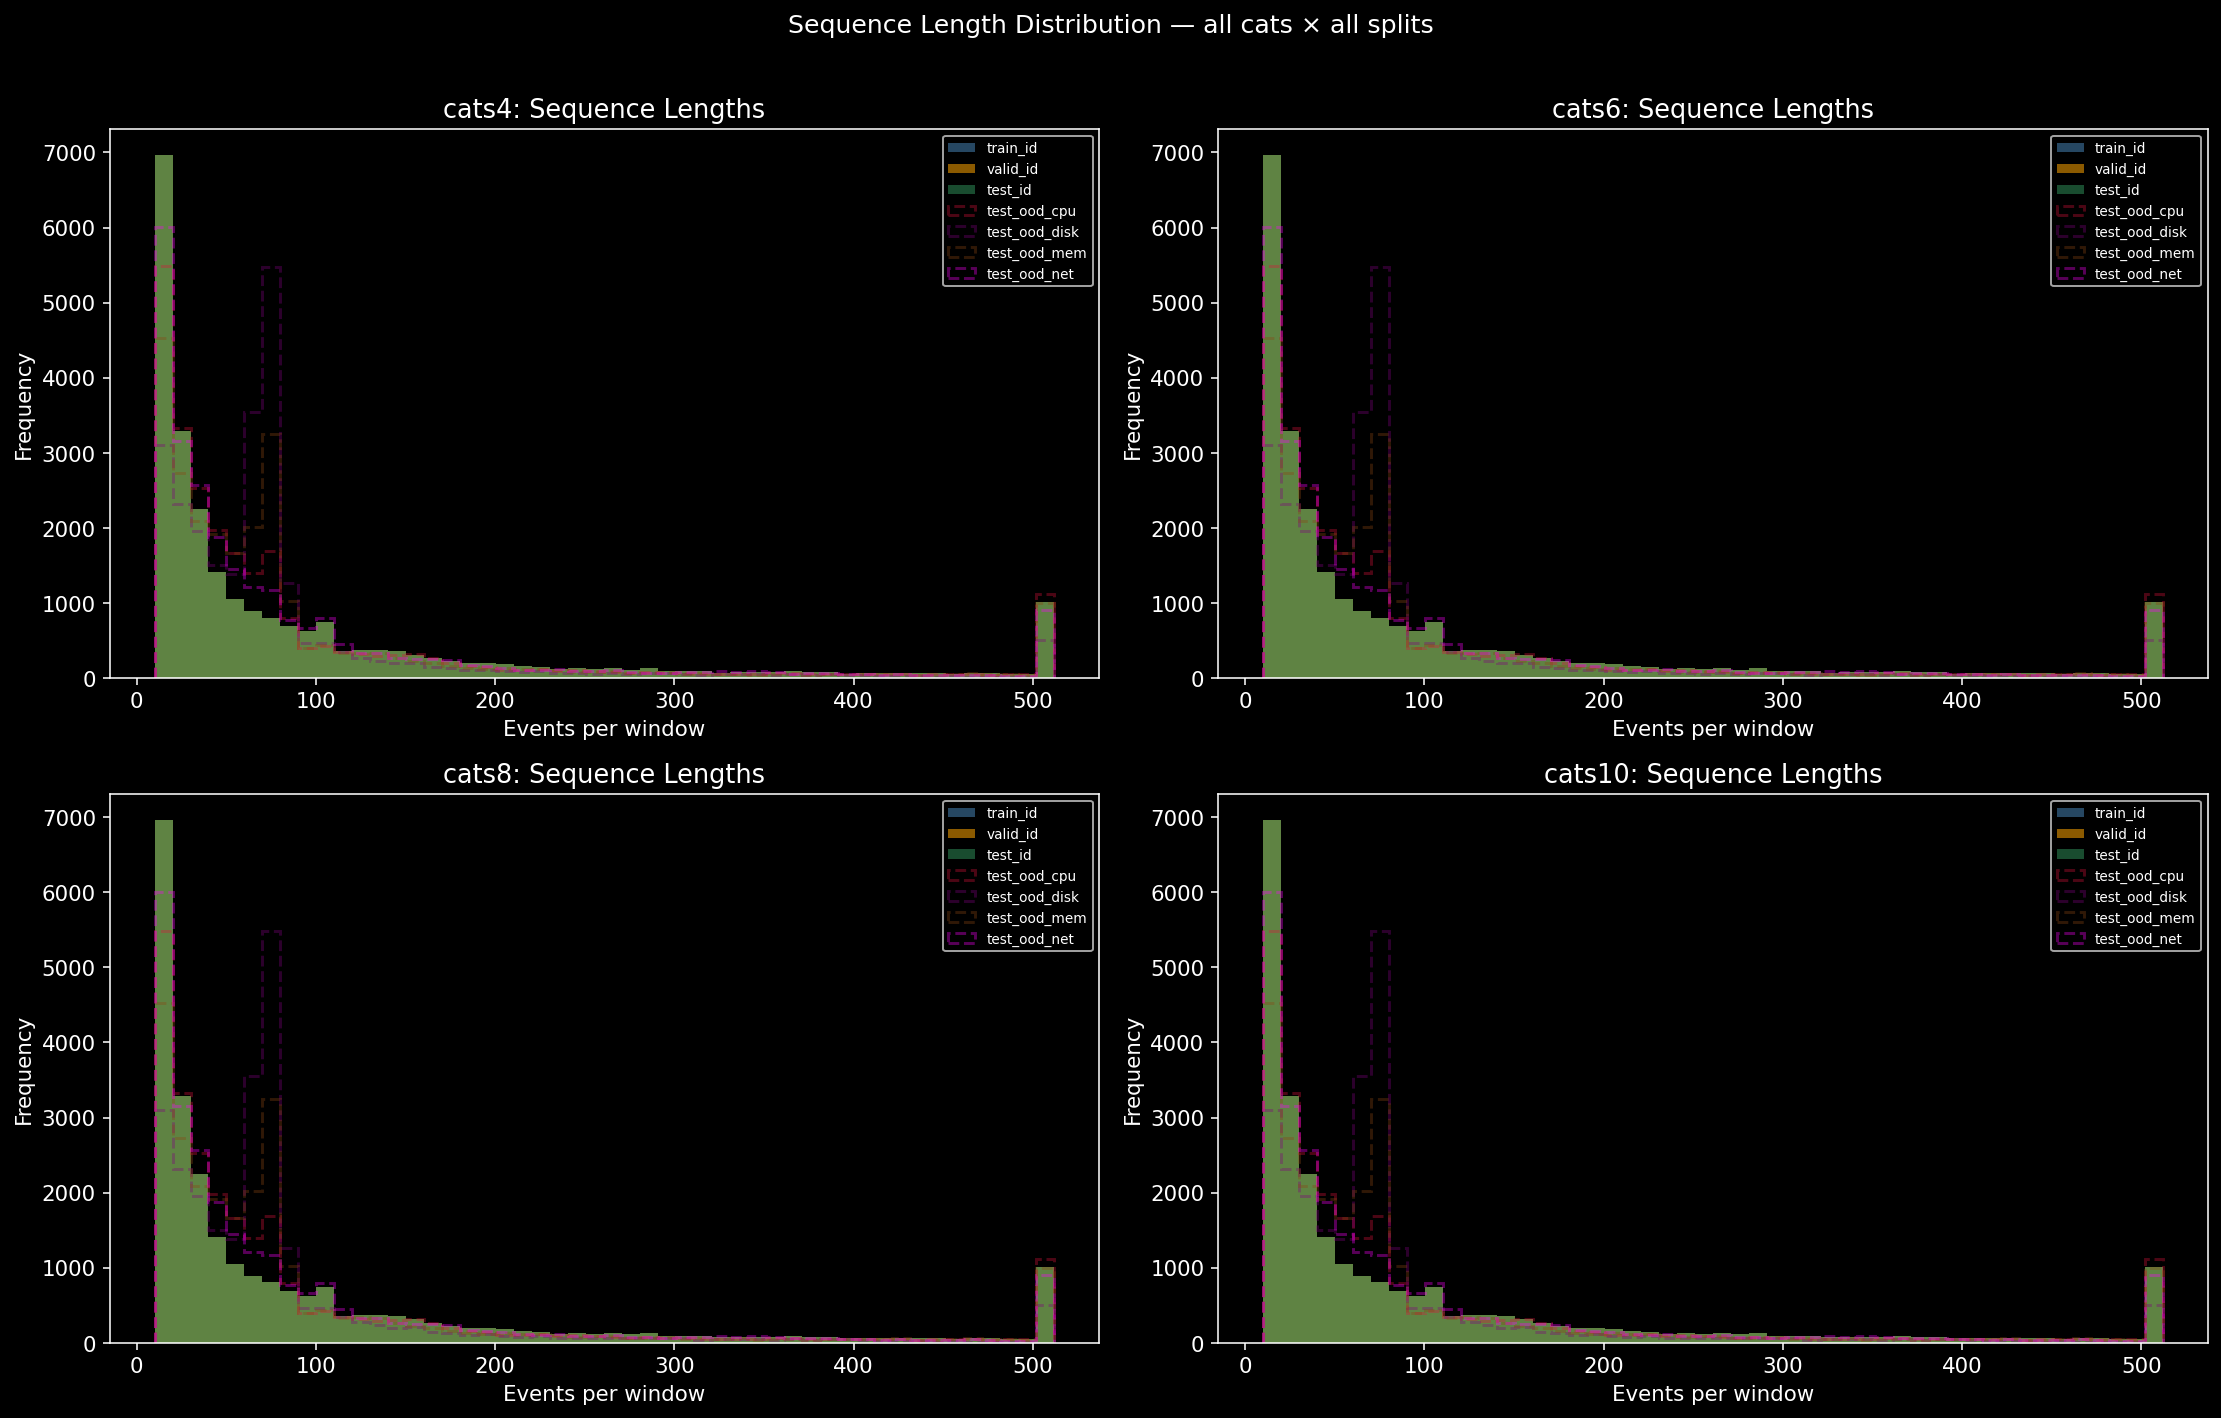

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, cats in zip(axes, CATS_LIST):
    d_data = all_data[cats]
    for split, col in zip(["train_id","valid_id","test_id"], COLORS_NORMAL):
        if split not in d_data: continue
        ax.hist(d_data[split][SEQ_LEN_KEY].ravel(), bins=50,
                alpha=0.55, label=split, color=col)
    for atype, col in zip(ANOMALY_TYPES, COLORS_ANOMALY):
        sp = f"test_ood_{atype}"
        if sp not in d_data: continue
        ax.hist(d_data[sp][SEQ_LEN_KEY].ravel(), bins=50,
                alpha=0.35, label=sp, color=col, linestyle="dashed",
                histtype="step", linewidth=1.5)
    ax.set_title(f"cats{cats}: Sequence Lengths")
    ax.set_xlabel("Events per window"); ax.set_ylabel("Frequency")
    ax.legend(fontsize=7)

plt.suptitle("Sequence Length Distribution — all cats × all splits", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("fig_seq_lengths_all_cats.png", bbox_inches="tight")
plt.show()


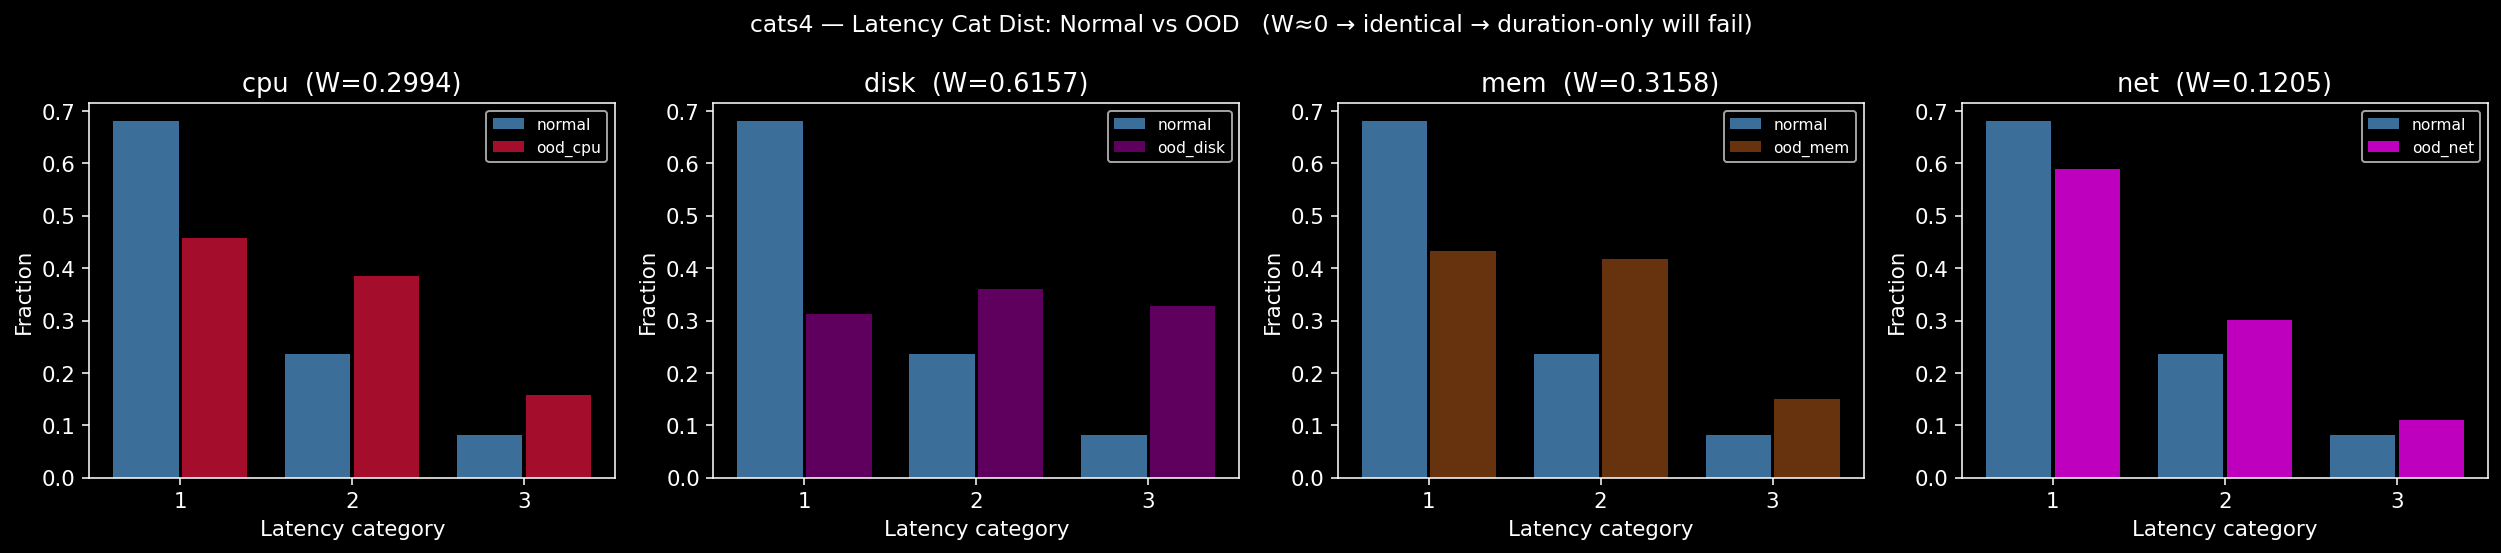

cats4: Wasserstein distances above — near-zero = no latency signal


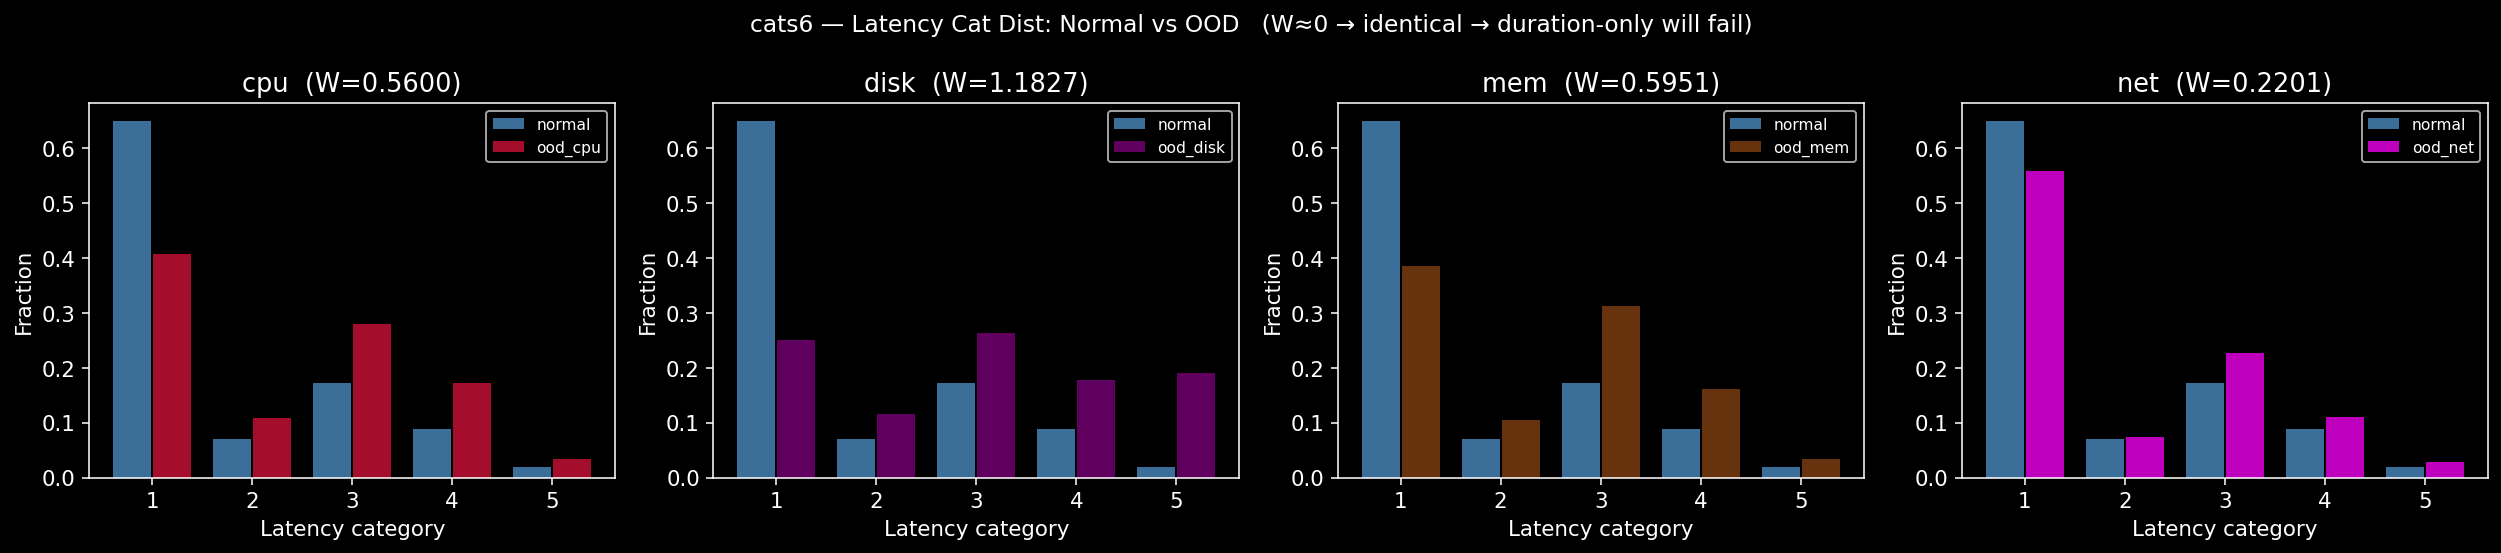

cats6: Wasserstein distances above — near-zero = no latency signal


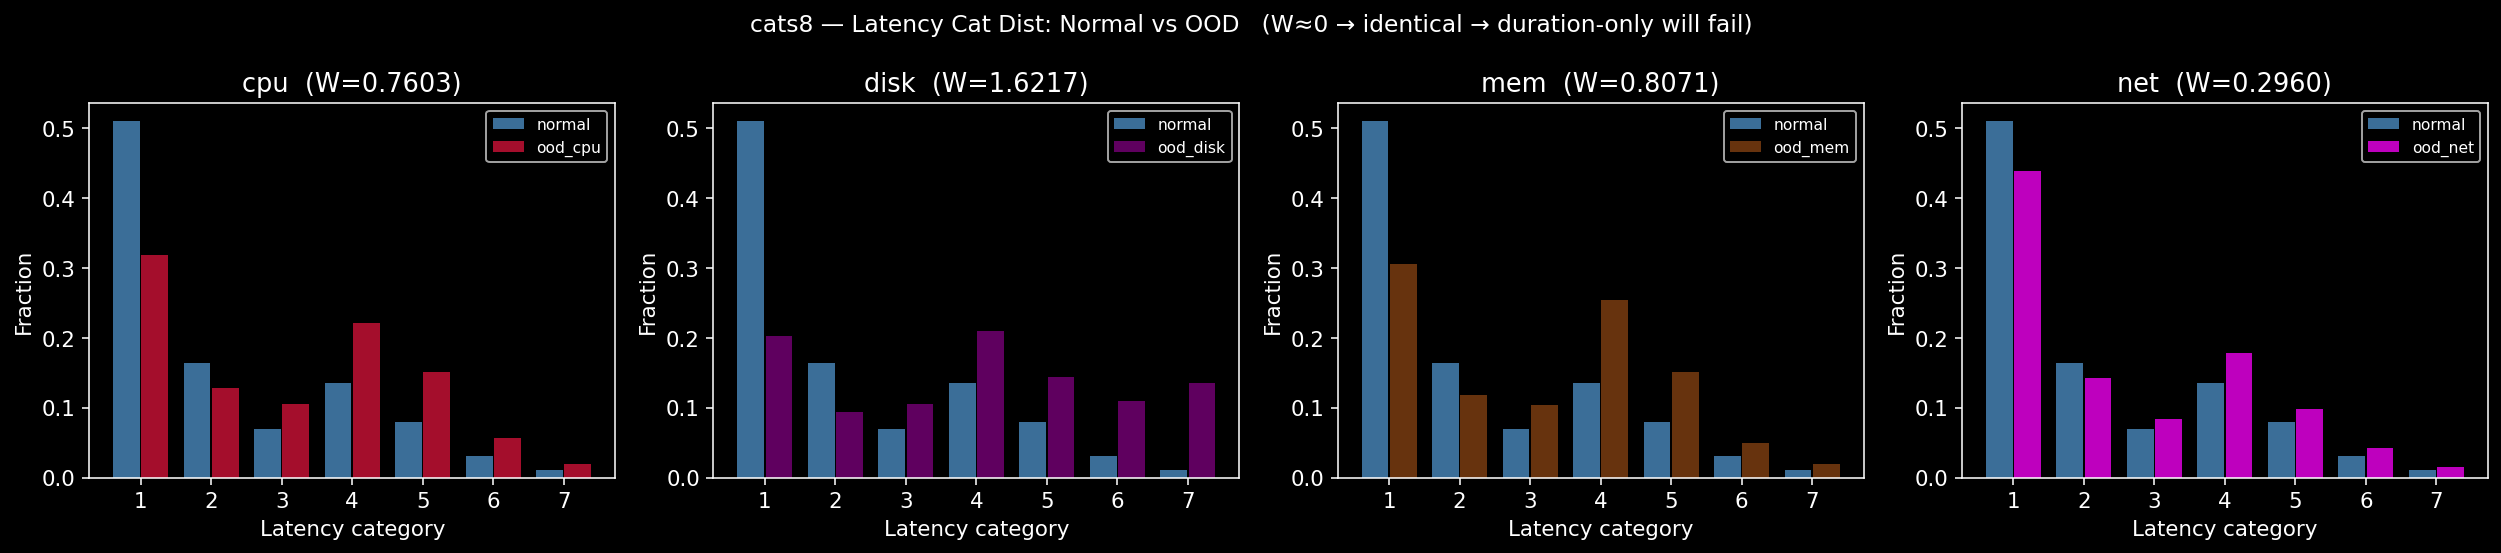

cats8: Wasserstein distances above — near-zero = no latency signal


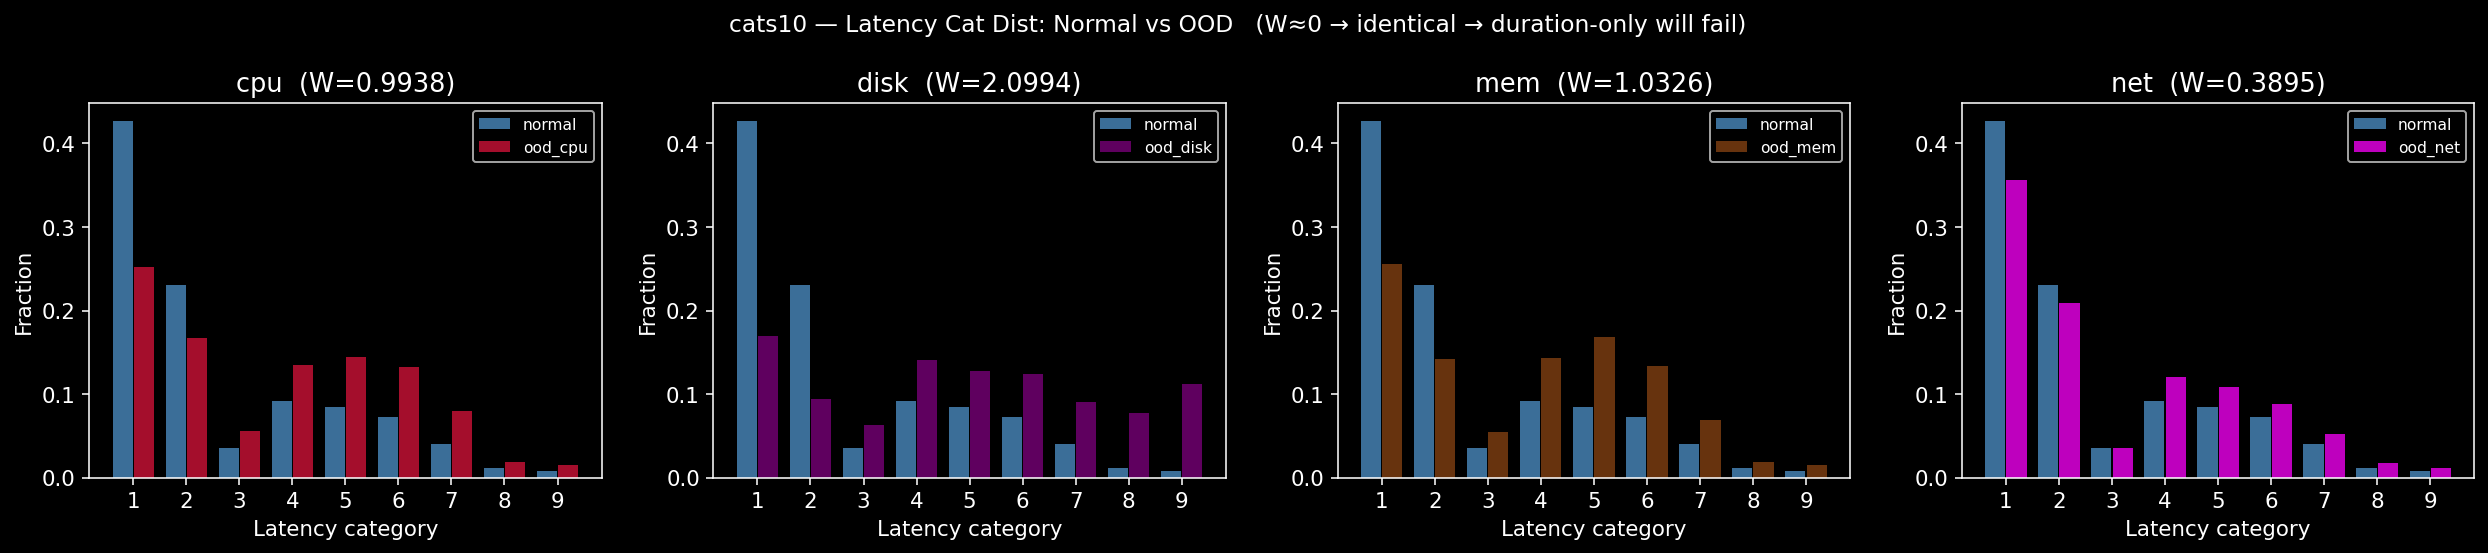

cats10: Wasserstein distances above — near-zero = no latency signal


In [8]:
# This is the key plot that explains why duration-only failed.
# If normal and OOD bars look identical → latency signal absent.

for cats in CATS_LIST:
    d_data = all_data[cats]
    if "test_id" not in d_data: continue

    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
    cat_bins  = np.arange(1, cats)   # categories 1..(cats-1), 0 is pad

    for ax, atype in zip(axes, ANOMALY_TYPES):
        sp = f"test_ood_{atype}"
        if sp not in d_data:
            ax.set_title(f"{atype} [missing]"); continue

        def cat_frac(d):
            c = d[LAT_CAT_KEY].ravel(); c = c[c > 0]
            return np.array([(c == b).mean() for b in cat_bins])

        nd = cat_frac(d_data["test_id"])
        od = cat_frac(d_data[sp])
        wd = wasserstein_distance(cat_bins, cat_bins, nd, od)

        x = np.arange(len(cat_bins))
        ax.bar(x - 0.2, nd, 0.38, label="normal",       color="steelblue", alpha=0.85)
        ax.bar(x + 0.2, od, 0.38, label=f"ood_{atype}", color=COLORS_ANOMALY[ANOMALY_TYPES.index(atype)], alpha=0.75)
        ax.set_title(f"{atype}  (W={wd:.4f})")
        ax.set_xlabel("Latency category"); ax.set_ylabel("Fraction")
        ax.set_xticks(x); ax.set_xticklabels(cat_bins)
        ax.legend(fontsize=8)

    plt.suptitle(f"cats{cats} — Latency Cat Dist: Normal vs OOD   "
                 f"(W≈0 → identical → duration-only will fail)", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"fig_latcat_ood_cats{cats}.png", bbox_inches="tight")
    plt.show()
    print(f"cats{cats}: Wasserstein distances above — near-zero = no latency signal")


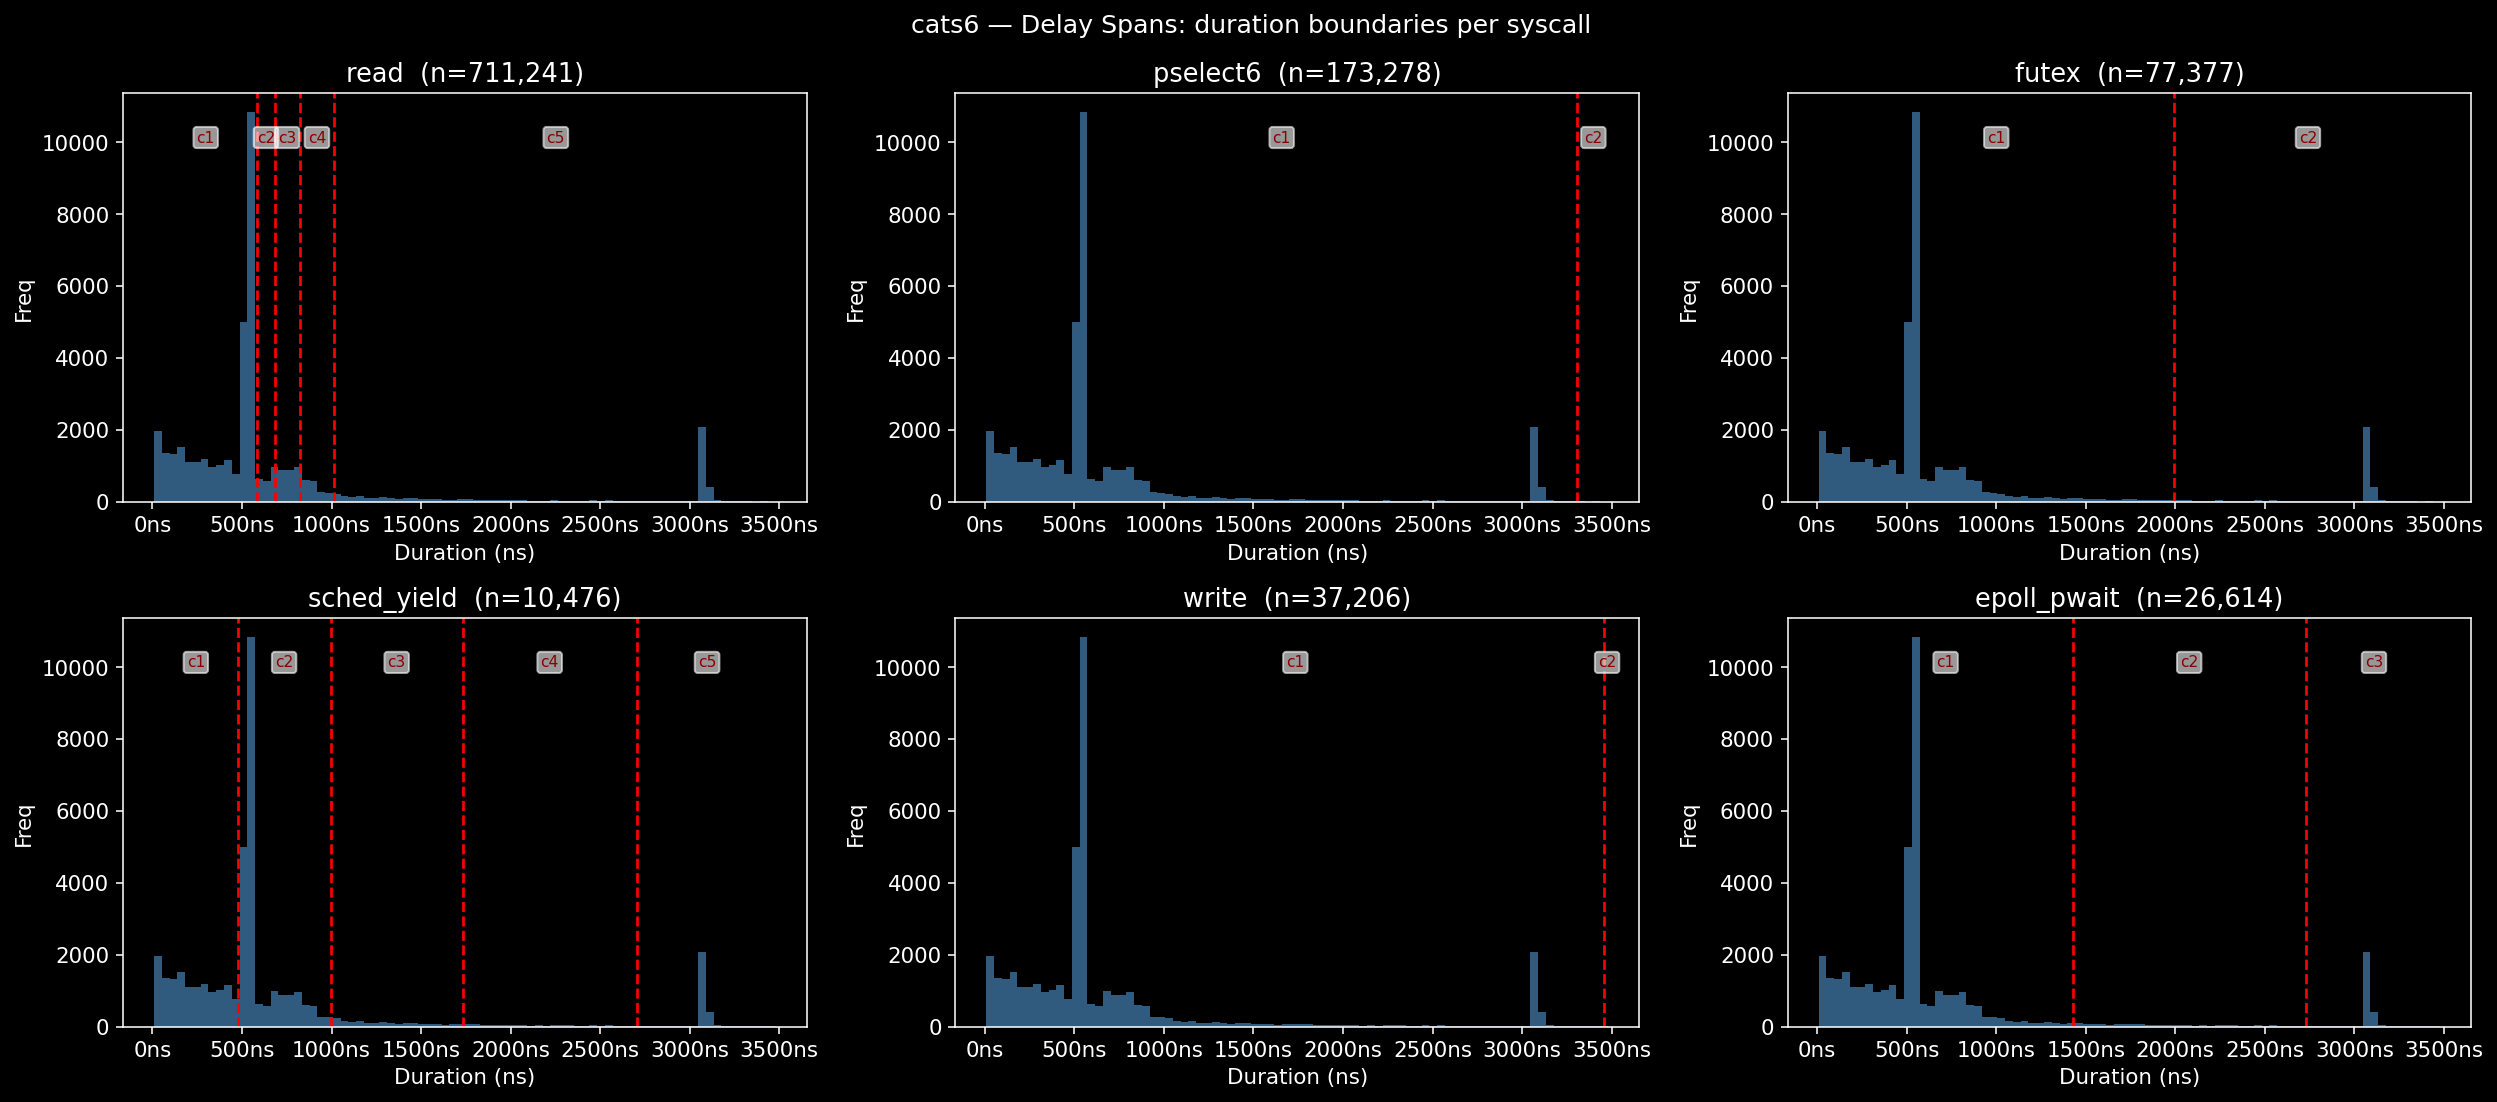

In [9]:
# Shows the quantile-based bin boundaries built from normal/run01 training data.
# Pick the 6 most common syscalls automatically.

cats = 6
dict_sys, _ = vocabs[cats]
ds = delay_all[cats]
d_train = all_data[cats]["train_id"]

idx2word = {v: k for k, v in dict_sys.word2idx.items()}
calls_flat = d_train["call"].ravel()
counter    = Counter(calls_flat[calls_flat > 0].tolist())
top_sysc   = [idx2word.get(i, f"id={i}") for i, _ in counter.most_common(30)]
# Keep only those that appear in delay_spans
top_sysc_ds = [s for s in top_sysc if s in ds][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

for ax, syscall in zip(axes, top_sysc_ds):
    boundaries, cnt = ds[syscall]
    dur   = d_train["duration"].ravel()
    entry = d_train["entry"].ravel()
    # exit events only (entry==2), positive, cap at 99th pct
    mask  = (entry == 2) & (dur > 0)
    if mask.sum() < 100:
        ax.set_title(f"{syscall} [too few exit events]"); continue
    cap   = np.percentile(dur[mask], 99)
    durs  = dur[mask & (dur < cap)]

    ax.hist(durs, bins=80, color="steelblue", alpha=0.7, edgecolor="none")
    for i, b in enumerate(boundaries):
        if b < cap:
            ax.axvline(b, color="red", linestyle="--", linewidth=1.4)
    edges = [durs.min()] + [b for b in boundaries if b < cap] + [cap]
    ylim  = ax.get_ylim()[1]
    for i in range(len(edges)-1):
        mid = (edges[i]+edges[i+1])/2
        ax.text(mid, ylim*0.88, f"c{i+1}", ha="center", fontsize=8, color="darkred",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))
    ax.set_title(f"{syscall}  (n={cnt:,})")
    ax.set_xlabel("Duration (ns)"); ax.set_ylabel("Freq")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x,_: f"{x/1000:.0f}µs" if x > 10000 else f"{x:.0f}ns"))

plt.suptitle(f"cats{cats} — Delay Spans: duration boundaries per syscall", fontsize=13)
plt.tight_layout()
plt.savefig(f"fig_delay_spans_cats{cats}.png", bbox_inches="tight")
plt.show()


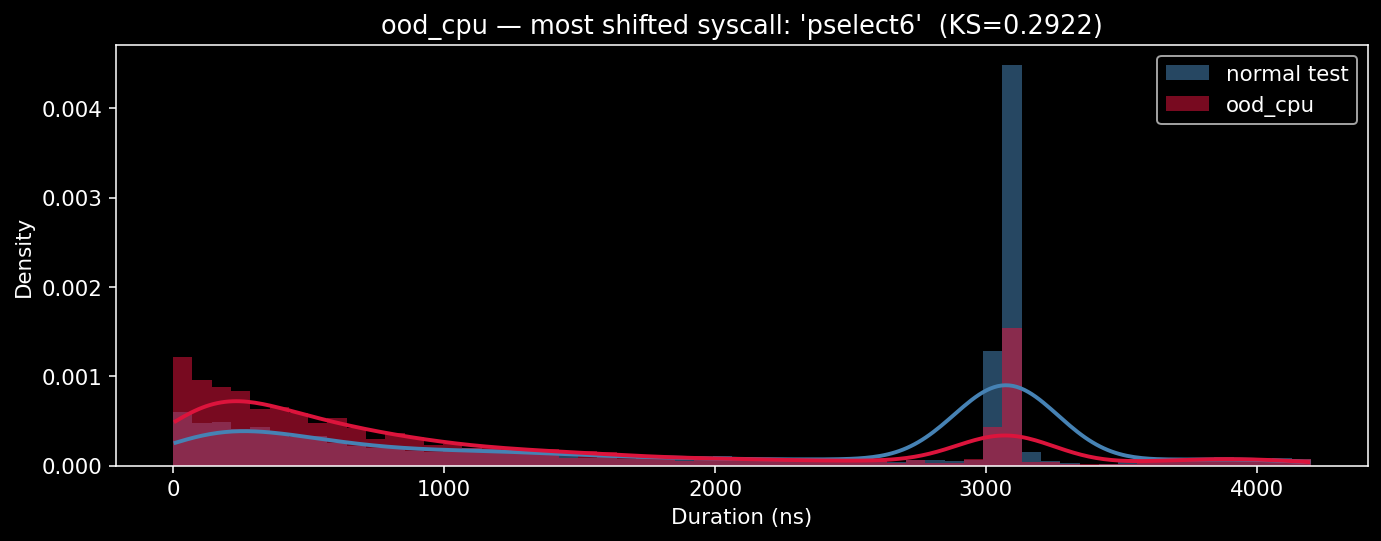

  ood_cpu : best KS=0.2922  syscall='pselect6'  → noticeable shift ✅
  n_normal=6,091  n_ood=1,994  cap=4200 ns



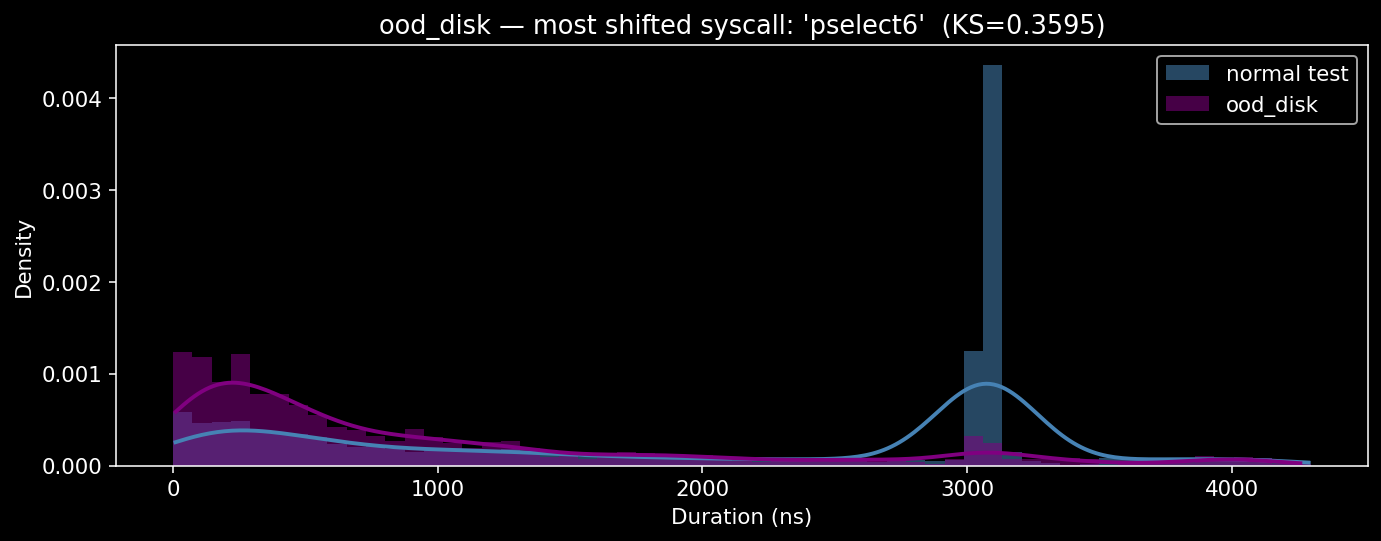

  ood_disk: best KS=0.3595  syscall='pselect6'  → noticeable shift ✅
  n_normal=6,122  n_ood=1,025  cap=4300 ns



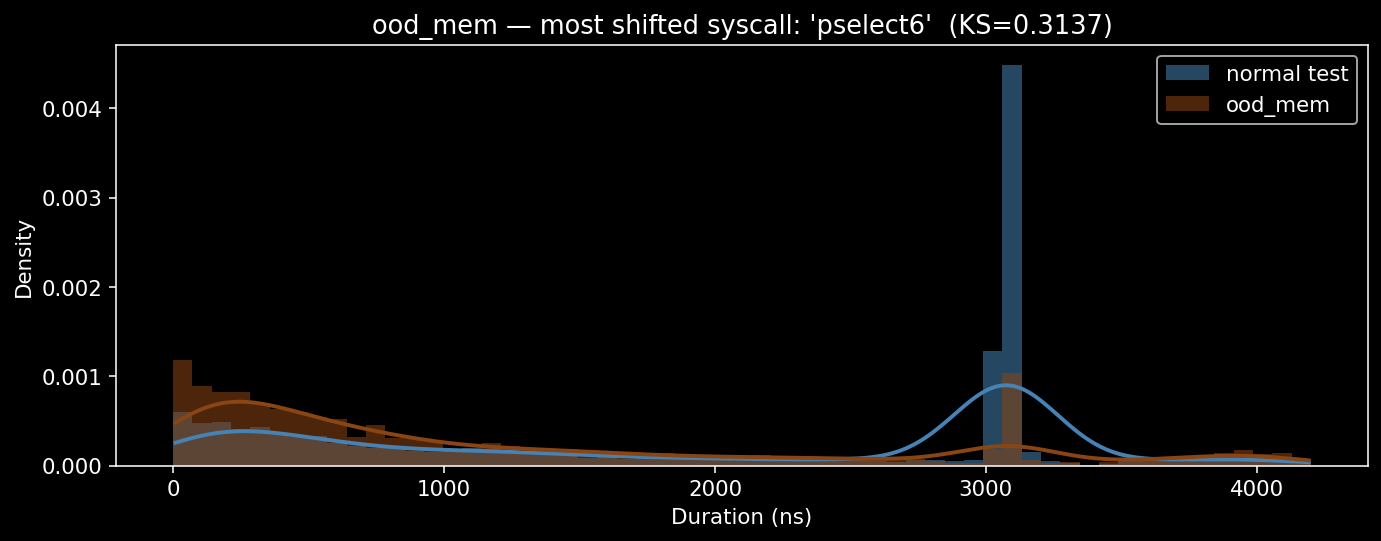

  ood_mem : best KS=0.3137  syscall='pselect6'  → noticeable shift ✅
  n_normal=6,091  n_ood=1,957  cap=4200 ns



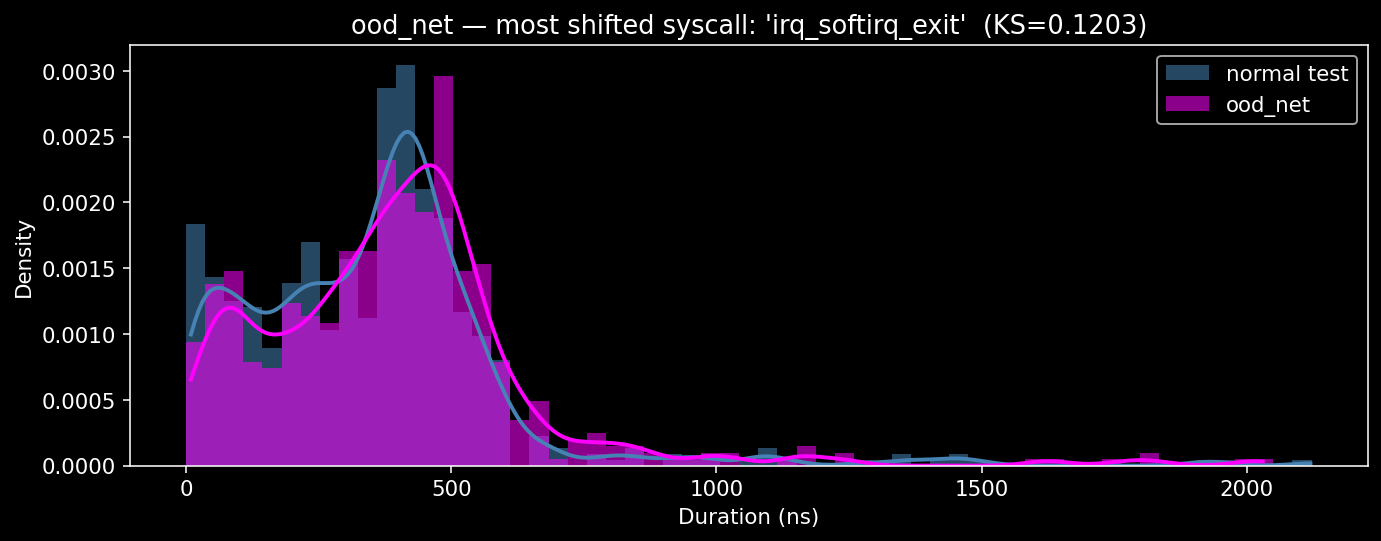

  ood_net : best KS=0.1203  syscall='irq_softirq_exit'  → noticeable shift ✅
  n_normal=621  n_ood=563  cap=2122 ns



In [10]:
cats = 6
d_data = all_data[cats]
dict_sys, _ = vocabs[cats]
idx2word = {v: k for k, v in dict_sys.word2idx.items()}
word2idx = dict_sys.word2idx

for atype in ANOMALY_TYPES:
    sp = f"test_ood_{atype}"
    if sp not in d_data or "test_id" not in d_data:
        print(f"ood_{atype}: split missing, skipping"); continue

    d_norm = d_data["test_id"]
    d_ood  = d_data[sp]

    # ── find syscall index with largest KS distance ────────────────────────
    def get_exit_durs_for_idx(d, syscall_idx, cap=500_000):
        """Extract exit-event durations for a specific syscall index."""
        calls = d["call"].ravel()
        durs  = d["duration"].ravel()
        entry = d["entry"].ravel()
        mask  = (calls == syscall_idx) & (entry == 2) & (durs > 0) & (durs < cap)
        return durs[mask]

    best_ks, best_idx, best_name = 0.0, None, None

    for idx in range(1, len(word2idx) + 1):
        name = idx2word.get(idx)
        if not name:
            continue
        n_d = get_exit_durs_for_idx(d_norm, idx)
        o_d = get_exit_durs_for_idx(d_ood,  idx)
        if len(n_d) < 200 or len(o_d) < 200:
            continue
        ks, _ = ks_2samp(n_d[:5000], o_d[:5000])
        if ks > best_ks:
            best_ks, best_idx, best_name = ks, idx, name

    if best_idx is None:
        print(f"ood_{atype}: no syscall with ≥200 exit events in both splits — "
              f"try increasing MAX_SHARDS"); continue

    # ── fetch durations using the fixed best_idx ───────────────────────────
    n_d = get_exit_durs_for_idx(d_norm, best_idx)
    o_d = get_exit_durs_for_idx(d_ood,  best_idx)

    if len(n_d) == 0 or len(o_d) == 0:
        print(f"ood_{atype}: empty duration arrays after fetch, skipping"); continue

    cap = np.percentile(np.concatenate([n_d, o_d]), 99)
    n_d = n_d[n_d < cap]
    o_d = o_d[o_d < cap]

    if len(n_d) == 0 or len(o_d) == 0:
        print(f"ood_{atype}: all values above 99th percentile cap, skipping"); continue

    atype_idx = ANOMALY_TYPES.index(atype)
    fig, ax = plt.subplots(figsize=(10, 4))
    bins = np.linspace(0, cap, 60)
    ax.hist(n_d, bins=bins, alpha=0.55, color="steelblue",
            label="normal test", density=True)
    ax.hist(o_d, bins=bins, alpha=0.55,
            color=COLORS_ANOMALY[atype_idx],
            label=f"ood_{atype}", density=True)

    # KDE overlays
    for arr, col in [(n_d, "steelblue"),
                     (o_d, COLORS_ANOMALY[atype_idx])]:
        if len(arr) > 50:
            try:
                kde = gaussian_kde(arr, bw_method=0.15)
                xs  = np.linspace(arr.min(), arr.max(), 300)
                ax.plot(xs, kde(xs), color=col, linewidth=2)
            except np.linalg.LinAlgError:
                pass   # singular bandwidth matrix — skip KDE, hist is enough

    ax.set_title(f"ood_{atype} — most shifted syscall: '{best_name}'  "
                 f"(KS={best_ks:.4f})")
    ax.set_xlabel("Duration (ns)")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    fname = f"fig_dur_shift_{atype}_{best_name}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()

    signal_str = ("noticeable shift ✅" if best_ks > 0.10
                  else "minimal shift ❌ — duration signal absent at kernel level")
    print(f"  ood_{atype:<4}: best KS={best_ks:.4f}  syscall='{best_name}'  → {signal_str}")
    print(f"  n_normal={len(n_d):,}  n_ood={len(o_d):,}  cap={cap:.0f} ns\n")


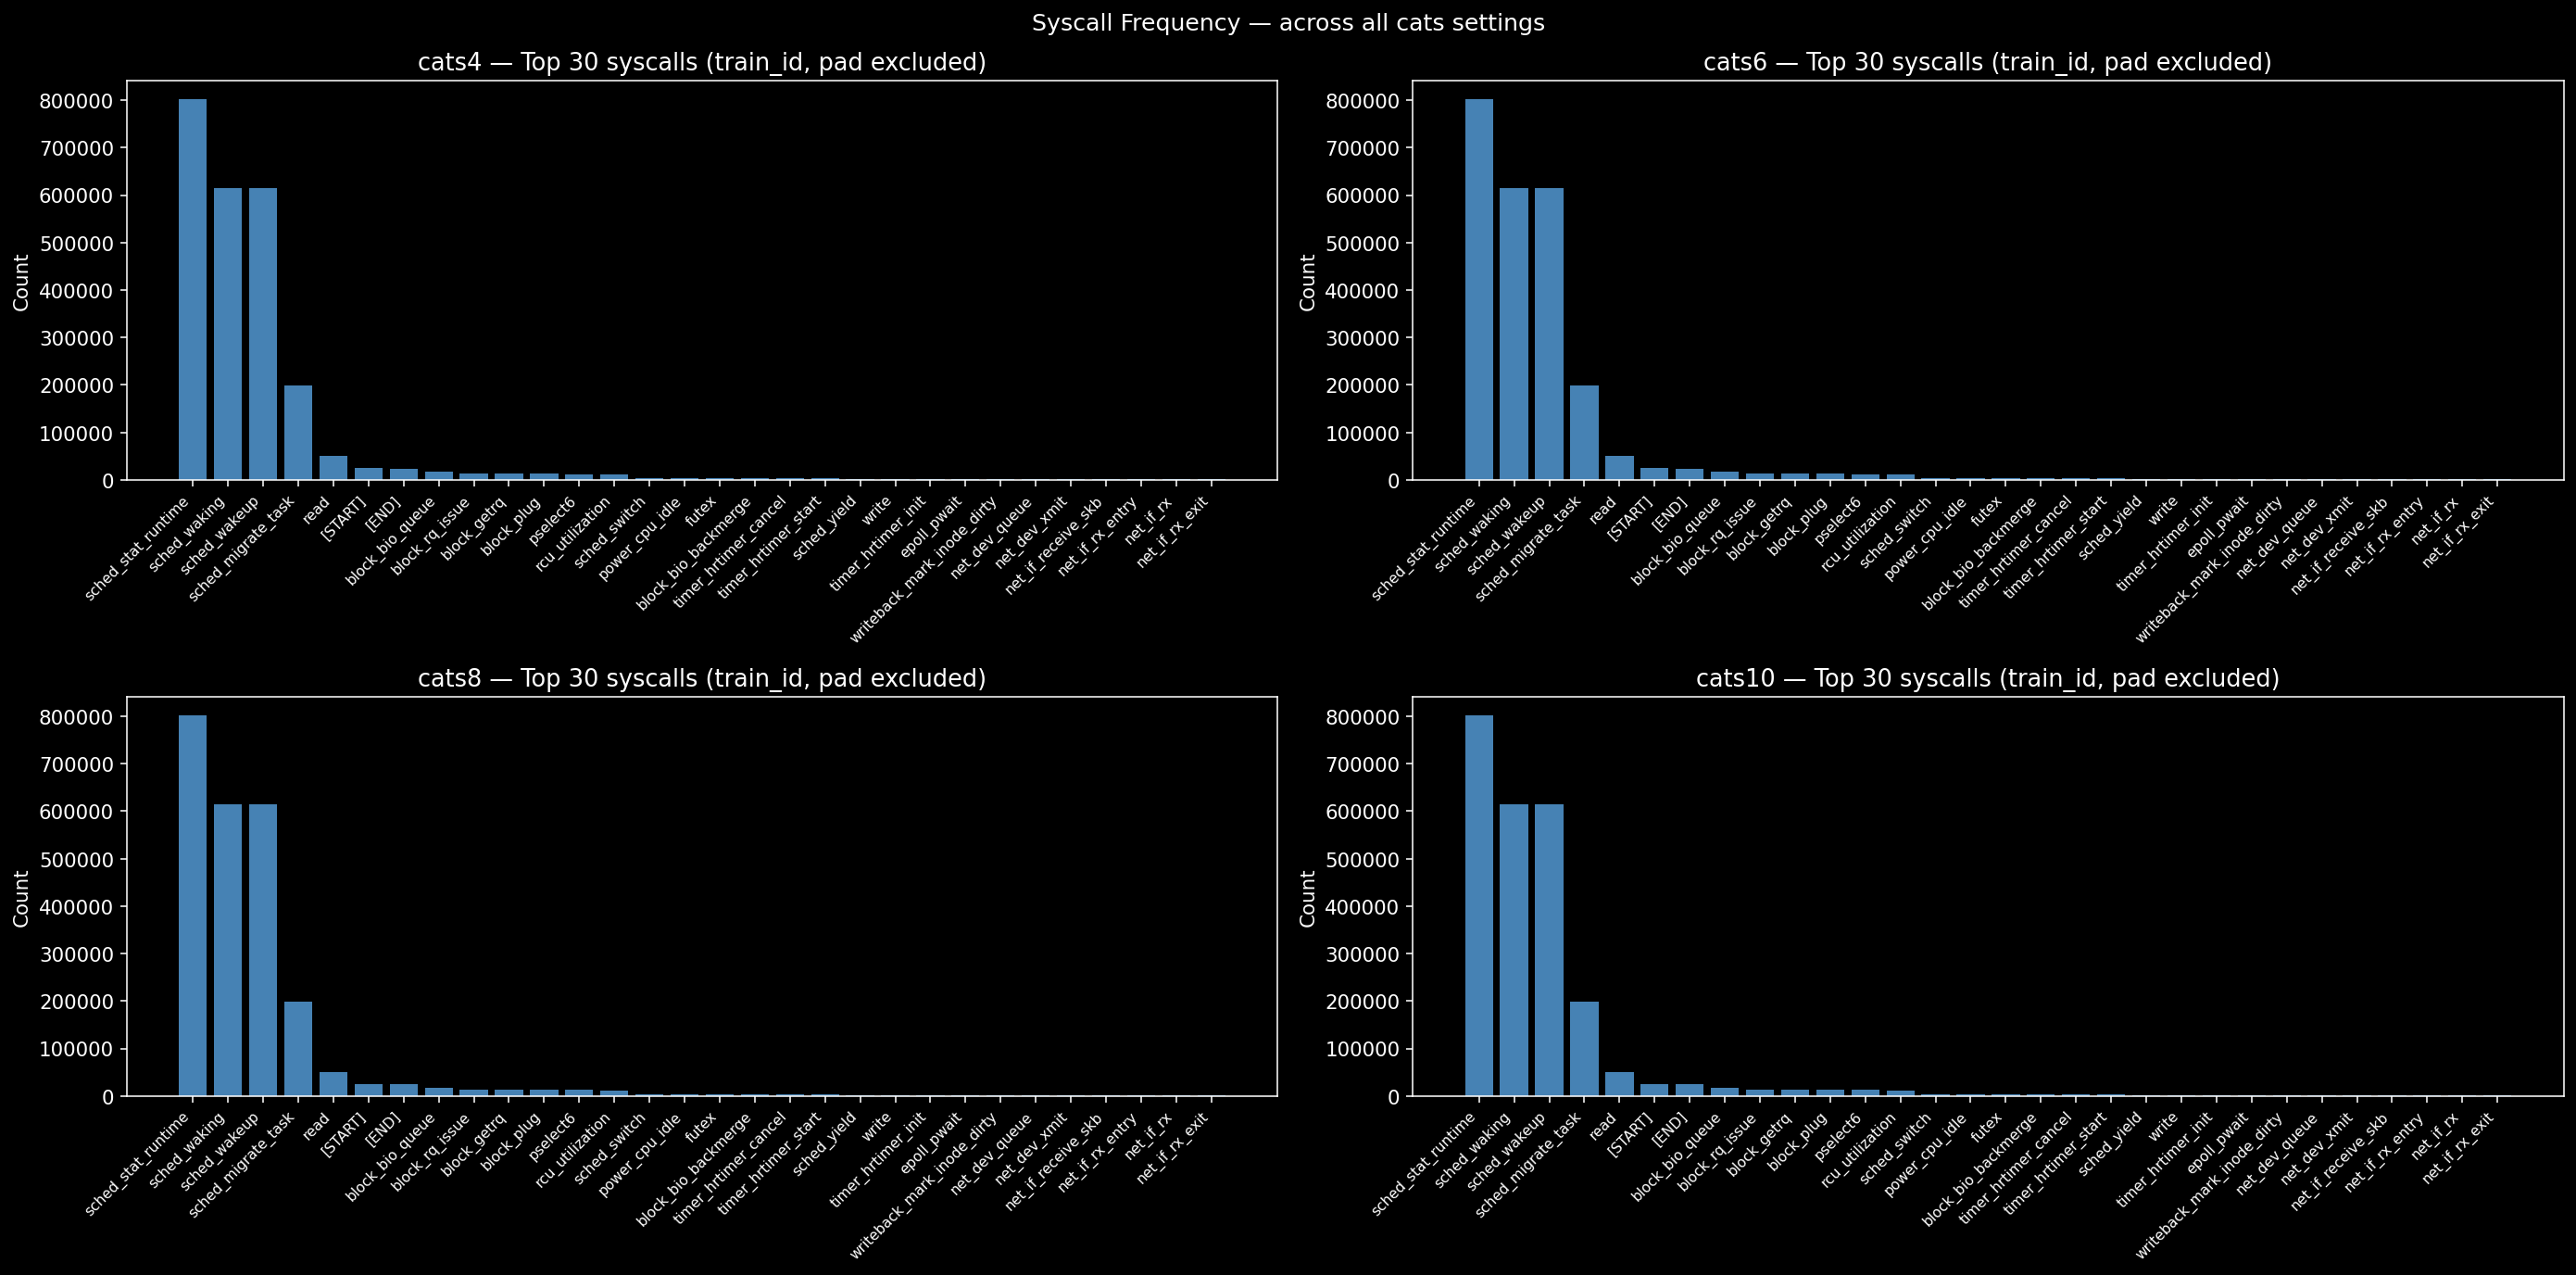

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.ravel()

for ax, cats in zip(axes, CATS_LIST):
    if cats not in vocabs or "train_id" not in all_data[cats]: continue
    d_sys, _ = vocabs[cats]
    i2w = {v: k for k, v in d_sys.word2idx.items()}

    calls = all_data[cats]["train_id"]["call"].ravel()
    lens  = all_data[cats]["train_id"][SEQ_LEN_KEY].ravel()
    step  = all_data[cats]["train_id"]["call"].shape[1]
    mask  = np.zeros(len(calls), dtype=bool)
    off   = 0
    for l in lens:
        mask[off:off+int(l)] = True
        off += step
    top30 = Counter(calls[mask].tolist()).most_common(30)
    names  = [i2w.get(i, f"id={i}") for i, _ in top30]
    counts = [c for _, c in top30]

    ax.bar(range(len(names)), counts, color="steelblue")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"cats{cats} — Top 30 syscalls (train_id, pad excluded)")
    ax.set_ylabel("Count")

plt.suptitle("Syscall Frequency — across all cats settings", fontsize=13)
plt.tight_layout()
plt.savefig("fig_top_syscalls_all_cats.png", bbox_inches="tight")
plt.show()


In [12]:
# Checks whether train/valid/test_id are actually independent.
# If they share the same shards or same event statistics they are NOT independent.
# This is the source of the threshold overfitting problem identified earlier.

print("=" * 68)
print("SPLIT OVERLAP DIAGNOSTIC")
print("=" * 68)

for cats in CATS_LIST:
    d_data = all_data[cats]
    pdir   = cats_dir(cats)
    print(f"\ncats{cats}:")

    # Shard file sizes (if identical, same data was written twice)
    for split_a, split_b in [("train_id","valid_id"),
                              ("train_id","test_id"),
                              ("valid_id","test_id")]:
        shards_a = sorted(glob.glob(os.path.join(pdir, split_a, "shard_*.npz")))
        shards_b = sorted(glob.glob(os.path.join(pdir, split_b, "shard_*.npz")))
        sizes_a  = set(os.path.getsize(p) for p in shards_a)
        sizes_b  = set(os.path.getsize(p) for p in shards_b)
        overlap  = sizes_a & sizes_b
        print(f"  {split_a} vs {split_b}: identical shard sizes = {len(overlap)} "
              f"{'❌ SAME DATA — no real split!' if overlap else '✅ different'}")

    # First-call fingerprint (first event of first sequence)
    if all(s in d_data for s in ["train_id","valid_id","test_id"]):
        fps = {s: tuple(d_data[s]["call"][0, :5].tolist())
               for s in ["train_id","valid_id","test_id"]}
        unique_fps = len(set(fps.values()))
        print(f"  First-sequence fingerprint unique count: {unique_fps}/3 "
              f"{'✅' if unique_fps == 3 else '⚠️  splits may overlap'}")

    # Meta.json nsequences
    for split in ["train_id","valid_id","test_id"]:
        m = all_meta[cats].get(split, {})
        print(f"  {split:<12} meta nsequences={m.get('nsequences','?')}  "
              f"is_train={m.get('is_train','?')}  "
              f"is_anomaly={m.get('is_anomaly','?')}")


SPLIT OVERLAP DIAGNOSTIC

cats4:
  train_id vs valid_id: identical shard sizes = 64 ❌ SAME DATA — no real split!
  train_id vs test_id: identical shard sizes = 64 ❌ SAME DATA — no real split!
  valid_id vs test_id: identical shard sizes = 64 ❌ SAME DATA — no real split!
  First-sequence fingerprint unique count: 1/3 ⚠️  splits may overlap
  train_id     meta nsequences=?  is_train=?  is_anomaly=0
  valid_id     meta nsequences=?  is_train=?  is_anomaly=0
  test_id      meta nsequences=?  is_train=?  is_anomaly=0

cats6:
  train_id vs valid_id: identical shard sizes = 64 ❌ SAME DATA — no real split!
  train_id vs test_id: identical shard sizes = 64 ❌ SAME DATA — no real split!
  valid_id vs test_id: identical shard sizes = 64 ❌ SAME DATA — no real split!
  First-sequence fingerprint unique count: 1/3 ⚠️  splits may overlap
  train_id     meta nsequences=?  is_train=?  is_anomaly=0
  valid_id     meta nsequences=?  is_train=?  is_anomaly=0
  test_id      meta nsequences=?  is_train=?  is

In [13]:
print("\n" + "=" * 68)
print("DATASET REPORT CARD")
print("=" * 68)
print(f"{'cats':<6} {'split':<22} {'n_seqs':>8} {'avg_len':>8} "
      f"{'lat_ent':>8} {'anom_flag':>10}")
print("─" * 68)

for cats in CATS_LIST:
    d_data = all_data[cats]
    for split in SPLITS:
        if split not in d_data: continue
        d    = d_data[split]
        cats_arr = d[LAT_CAT_KEY].ravel(); cats_arr = cats_arr[cats_arr > 0]
        bc   = np.bincount(cats_arr.astype(int))
        freq = bc[1:] / bc[1:].sum()
        ent  = -np.sum(freq * np.log2(freq + 1e-12))
        lens = d[SEQ_LEN_KEY].ravel()
        ia   = int(d["is_anomaly"].ravel()[0])
        print(f"cats{cats}  {split:<22} {len(d['call']):>8,} {lens.mean():>8.1f} "
              f"{ent:>8.3f} {str(ia):>10}")
    print()

print("Interpretation:")
print("  lat_ent ≈ log2(n_cats-1) → balanced bins  ✅")
print("  lat_ent << 1.0           → collapsed bins  ❌ (duration-only will fail)")
print("  All splits should exist in all cats variants")
print("\n✅ Analysis complete.")



DATASET REPORT CARD
cats   split                    n_seqs  avg_len  lat_ent  anom_flag
────────────────────────────────────────────────────────────────────
cats4  train_id                 25,000     98.5    1.165          0
cats4  valid_id                 25,000     98.5    1.165          0
cats4  test_id                  25,000     98.5    1.165          0
cats4  valid_ood_cpu            25,000     93.3    1.466          1
cats4  valid_ood_disk           25,000     82.9    1.582          1
cats4  valid_ood_mem            25,000     94.2    1.458          1
cats4  valid_ood_net            25,000     90.6    1.321          1
cats4  test_ood_cpu             25,000     93.3    1.466          1
cats4  test_ood_disk            25,000     82.9    1.582          1
cats4  test_ood_mem             25,000     94.2    1.458          1
cats4  test_ood_net             25,000     90.6    1.321          1

cats6  train_id                 25,000     98.5    1.528          0
cats6  valid_id          